# **Libraries**

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

# **Functions**

In [3]:
def quick_edit(x, y):
    from ipywidgets import interact, FloatSlider, IntSlider, VBox
    import plotly.graph_objects as go
    from IPython.display import display
    
    y_ed = y.copy()
    fig = go.FigureWidget()
    fig.add_scatter(x=x, y=y_ed, mode='lines+markers', marker=dict(size=8))
    
    # Слайдеры
    idx_slider = IntSlider(min=0, max=len(x)-1, step=1, value=0, description='Index:')
    y_slider = FloatSlider(min=float(min(y) / 2), max=float(max(y) * 2), 
                          value=float(y[0]), step=(max(y)-min(y))/100,
                          description='Y:', readout_format='.4f')
    
    def update(idx, val):
        y_ed[idx] = val
        fig.data[0].y = y_ed
    
    def on_click(trace, points, selector):
        if points.point_inds:
            idx = points.point_inds[0]
            idx_slider.value = idx
            y_slider.value = y_ed[idx]
    
    fig.data[0].on_click(on_click)
    
    # Сначала показываем график, потом слайдеры
    display(fig)
    interact(update, idx=idx_slider, val=y_slider)
    
    return y_ed

# **Data**

### for intagreation

In [4]:
poni_saxs = r"E:\Nps Cu\IHSC 1872\SAXS_1p4m_12keV.poni"
ai_saxs = pyFAI.load(poni_saxs)

poni_waxs = r"E:\Nps Cu\IHSC 1872\WAXS_1p4m_12keV.poni"
ai_waxs = pyFAI.load(poni_waxs)

mask_saxs = r"E:\Nps Cu\IHSC 1872\MASK_SAXS_1p4m_12keV.edf"
img_mask_saxs = fabio.open(mask_saxs).data

mask_waxs = r"E:\Nps Cu\IHSC 1872\MASK_WAXS_1p4m_12keV.edf"
img_mask_waxs = fabio.open(mask_waxs).data

### Samples

In [5]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_05_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_beforetrans\CuPE_0_5perc_1_4m_beforetrans_Isoth_190C_30min'
Cu_05_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_0_5perc_1_4m_aftertrans\CuPE_0_5perc_1_4m_aftertrans_RT_measurement'
Cu_05_after = BM26_experiment(path)


In [6]:
path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Ht_190C_10Kpm'
Cu_3_heat = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_beforetrans\CuPE_3perc_1_4m_beforetrans_Isoth_190C'
Cu_3_iso = BM26_experiment(path)

path = r'E:\Nps Cu\IHSC 1872\CuPE_3perc_1_4m_aftertrans\CuPE_3perc_1_4m_aftertrans_RT_measurement'
Cu_3_after = BM26_experiment(path)

In [7]:
T_array_3 = Cu_3_heat.get_T_profile()
T_array_05 = Cu_05_heat.get_T_profile()

Found 89 EDF files in SAXS
Found 88 EDF files in SAXS


# **Figures**

In [8]:
q, I_array = Cu_3_iso.integrate1d_WAXS(ai_waxs, 10000, mask = img_mask_waxs)

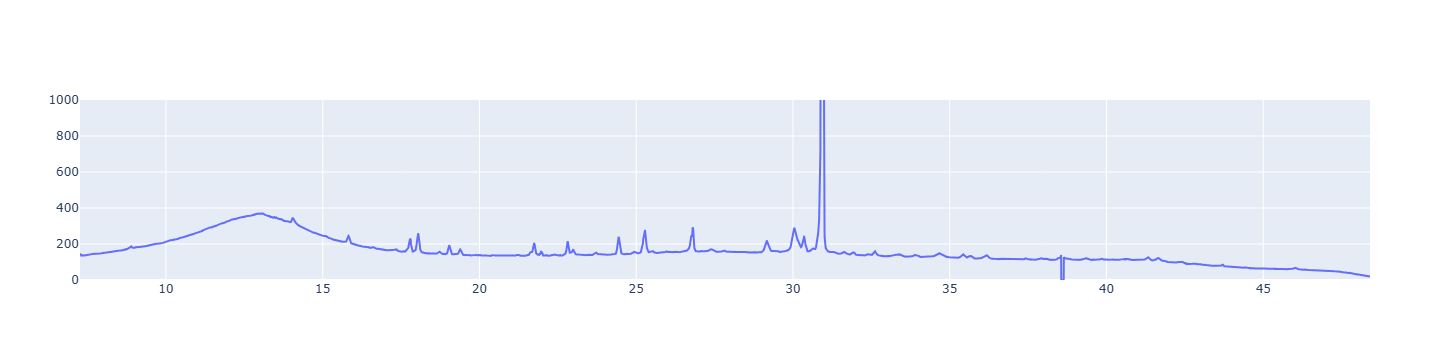

In [29]:

x, y = q, I_array[0]

q_lim1, q_lim2 = 11.2, 11.4
q_lim3, q_lim4 = 12.9, 13.09

mask1 = (x < q_lim1) + (x > q_lim2)
mask2 = (x < q_lim3) + (x > q_lim4)

x_new = x[mask1 & mask2]
y_new = y[mask1 & mask2]
import plotly.graph_objects as go

fig = go.Figure(data=go.Scatter(x=x_new, y=y_new, mode='lines'))
fig.update_layout(yaxis_range=[0, 1000])
fig.show()


In [99]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))

# Создаем цветовую карту
norm = plt.Normalize(min(T_array), max(T_array))
colors = plt.cm.plasma(norm(T_array))

# Построение каждой кривой со сдвигом
vertical_shift = 0
shift_increment = max(np.max(I_array)) * 0.8  # Сдвиг между кривыми

for i, (I_spectrum, temp, color) in enumerate(zip(I_array, T_array, colors)):
    # Либо фиксированный сдвиг, либо пропорциональный температуре
    vertical_shift = i * shift_increment  # Равномерный сдвиг
    # vertical_shift = (temp - min(T_array)) * shift_increment / (max(T_array)-min(T_array))
    
    plt.plot(q, I_spectrum + vertical_shift, color=color, linewidth=1, alpha=0.8)
    
    # Подпись температуры
    if i % max(1, len(T_array)//10) == 0:  # Подписываем каждую 10-ю кривую
        plt.text(q[-1], I_spectrum[-1] + vertical_shift, f'{temp:.1f}°C', 
                fontsize=8, va='center', ha='left')

# Добавляем colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label('Температура, °C', fontsize=12)

plt.xlabel('q', fontsize=12)
plt.ylabel('Интенсивность + сдвиг', fontsize=12)
plt.title('Зависимость спектров от температуры', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TypeError: 'numpy.float32' object is not iterable

<Figure size 1400x800 with 0 Axes>

3
7
11
15
19
23
27
31
35
39
43
47
51
55
59


(0.0, 5000.0)

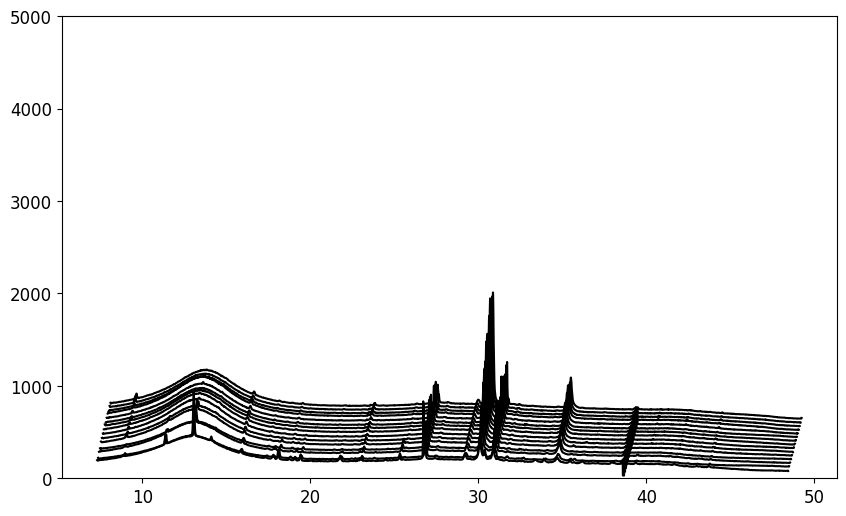

In [50]:
for i in range(len(I_array)):
    if (i + 1) % 4 == 0:
        print(i)
        plt.plot(q + i / 70, I_array[i] + i * 10, color='black')

plt.ylim(0, 5000)

In [38]:
2 * pi / 5.9

1.0649466622338282